In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

In [2]:
def NORM(X):
    X = np.matrix(X)
    return np.sqrt(np.trace(X.H@X))

def OP_NORM(X):
    X = np.matrix(X)
    v = np.linalg.eigvals(X.H@X)
    return np.real(np.sqrt(np.max(v)))
    

# Model definition

#### Parameters

In [3]:
n = 20
m = 5

L_norm = .5 

N = 20

dt = 0.02
Nt = 500

In [4]:
L = np.random.rand(n*n).reshape([n,n])
v = np.linalg.eigvals(L)
M = np.max(np.abs(v))
L = L - np.eye(n)*M
L = L/OP_NORM(L)*L_norm

R = np.zeros([m,n])
R[:m,:m] = np.eye(m)
J = np.zeros([n,m])
J[:m,:m] = np.eye(m)

In [5]:
ts = np.arange(Nt+1)*dt

## Simulation of the original model

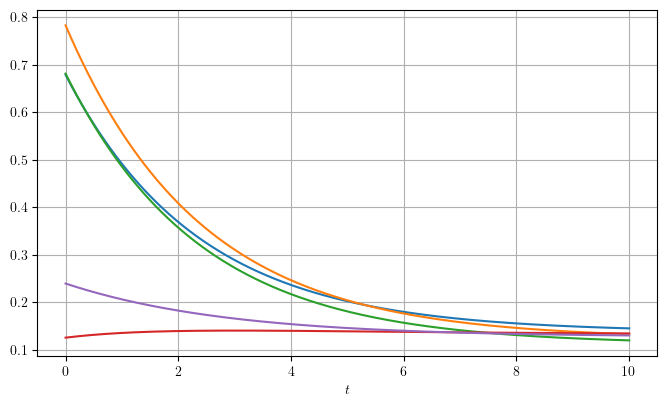

In [11]:
x_0 = J@R@np.random.rand(n)
 
A = sp.linalg.expm(L*dt)

x_t = x_0

ys = [R@x_t]
for j in range(Nt):
    x_t = A@x_t
    ys.append(R@x_t)

ys = np.array(ys).reshape([len(ts),m])

plt.figure(figsize=(16/2,9/2))
plt.plot(ts,ys)
plt.grid()
plt.xlabel(r'$t$')
plt.show()

# Approximation

In [7]:
Fs = [np.zeros([m,m])]

for k in range(1,N+1):
    F = R@np.linalg.matrix_power(L,k)@J /math.factorial(k-1)
    C = np.zeros_like(F)
    for h in range(1,k):
        C += Fs[k-h]@R@np.linalg.matrix_power(L,h)@J /math.factorial(h)
    Fs.append(F - C)


Es = [np.eye(m)]
for k in range(1,60):
    E = np.zeros([m,m])
    for s in range(1,k+1):
        if s<= N:
            E += Fs[s]@Es[k-s]/k
    Es.append(E)

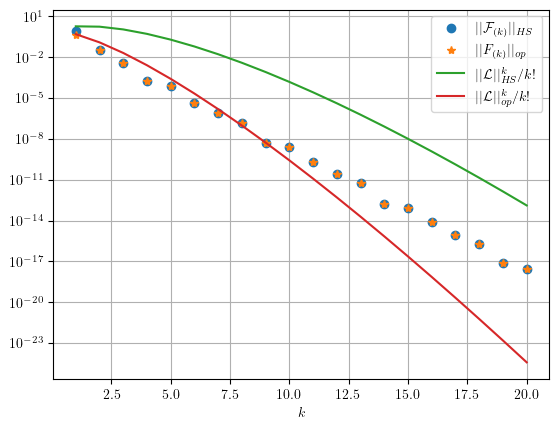

In [8]:
ks = np.arange(len(Fs))

norms_F = []
op_norms_F = []
for F in Fs:
    norms_F.append(NORM(F))
    op_norms_F.append(OP_NORM(F))

theoretical = [0]
op_theoretical = [0]
for k in ks[1:]:
    theoretical.append(NORM(L)**k/math.factorial(k))
    op_theoretical.append(OP_NORM(L)**k/math.factorial(k))

plt.figure()
plt.plot(ks[1:],norms_F[1:],'o',label=r'$||\mathcal{F}_{(k)}||_{HS}$')
plt.plot(ks[1:],op_norms_F[1:],'*',label=r'$||F_{(k)}||_{op}$')
plt.plot(ks[1:],theoretical[1:],label=r'$||\mathcal{L}||_{HS}^k/k!$')
plt.plot(ks[1:],op_theoretical[1:],label=r'$||\mathcal{L}||_{op}^k/k!$')
plt.yscale('log')
plt.grid()
plt.legend()
plt.xlabel(r'$k$')
plt.show()


df=pd.DataFrame(np.array([ks[1:],norms_F[1:],op_norms_F[1:],theoretical[1:],op_theoretical[1:]]).T, columns=['k','n','o','b','s'])
df.to_csv('../data/norm.csv', index=False)

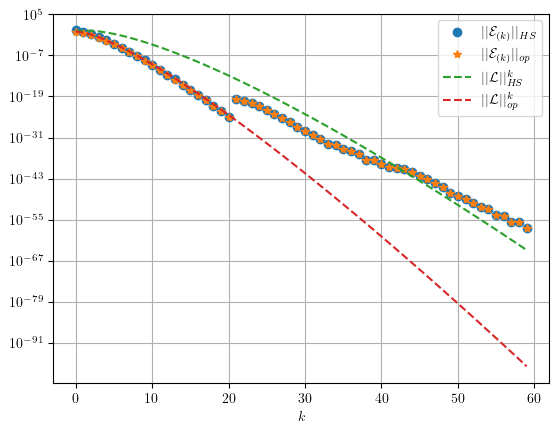

In [9]:
ks = np.arange(0,len(Es))
norms_E = []
op_norms_E = []
for E in Es:
    norms_E.append(NORM(E))
    op_norms_E.append(OP_NORM(E))

E_bound = []
op_E_bound = []
for k in ks:
    if k==0:
        E_bound.append(1)
        op_E_bound.append(1)
    else:
        b = NORM(L)**(k)/math.factorial(k)
        E_bound.append(b)
        b = OP_NORM(L)**(k)/math.factorial(k)
        op_E_bound.append(b)

plt.figure()
plt.plot(ks,norms_E,'o',label=r'$||\mathcal{E}_{(k)}||_{HS}$')
plt.plot(ks,op_norms_E,'*',label=r'$||\mathcal{E}_{(k)}||_{op}$')
plt.plot(ks,E_bound,'--',label=r'$||\mathcal{L}||_{HS}^k$')
plt.plot(ks,op_E_bound,'--',label=r'$||\mathcal{L}||_{op}^k$')
plt.yscale('log')
plt.xlabel(r'$k$')
plt.grid()
#plt.xlim([0,20])
#plt.ylim([10e-12,1])
plt.legend()
plt.show()

### Simulation of the second order approximation

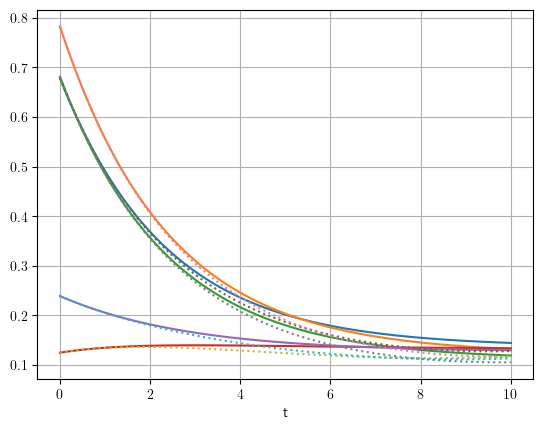

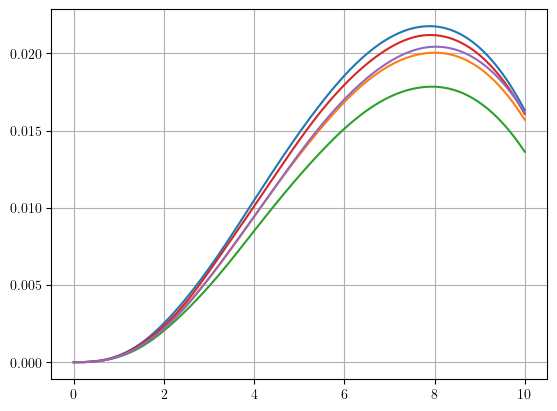

In [14]:
xc_0 = R@x_0
 
def fun(t,x):
    Ft = Fs[1] + t*Fs[2]
    return Ft@x

result = sp.integrate.solve_ivp(fun,[0,(Nt+1)*dt], xc_0, t_eval=ts)

ys_c = []
for j in range(result.y.shape[1]):
   ys_c.append(result.y[:,j].reshape([m,]))

ys_c = np.array(ys_c)

plt.figure()
plt.plot(ts,ys)
plt.plot(ts,ys_c,':')
plt.grid()
plt.xlabel('t')
plt.show()

plt.figure()
plt.plot(ts,ys-ys_c)
plt.grid()
plt.show()

### Comparison of different orders

In [15]:
def fun1(t,x):
    Ft = Fs[1] 
    return Ft@x

def fun2(t,x):
    Ft = Fs[1] + t*Fs[2] 
    return Ft@x

def fun3(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] 
    return Ft@x

def fun4(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] 
    return Ft@x

def fun5(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] 
    return Ft@x

def fun6(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6]
    return Ft@x

def fun7(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7]
    return Ft@x

def fun8(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8]
    return Ft@x

def fun9(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9]
    return Ft@x

def fun10(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10]
    return Ft@x

def fun11(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10] + t**10*Fs[11]
    return Ft@x

def fun12(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10] + t**10*Fs[11] + t**11*Fs[12]
    return Ft@x

def fun13(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10] + t**10*Fs[11] + t**11*Fs[12] + t**12*Fs[13]
    return Ft@x

def fun14(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10] + t**10*Fs[11] + t**11*Fs[12] + t**12*Fs[13] + t**13*Fs[14]
    return Ft@x

def fun15(t,x):
    Ft = Fs[1] + t*Fs[2] + t**2*Fs[3] + t**3*Fs[4] + t**4*Fs[5] + t**5*Fs[6] + t**6*Fs[7] + t**7*Fs[8] + t**8*Fs[9] + t**9*Fs[10] + t**10*Fs[11] + t**11*Fs[12] + t**12*Fs[13] + t**13*Fs[14] + t**14*Fs[15]
    return Ft@x

funs = [fun1,fun2,fun3,fun4,fun5,fun6,fun7,fun8,fun9,fun10,fun11,fun12,fun13,fun14,fun15]

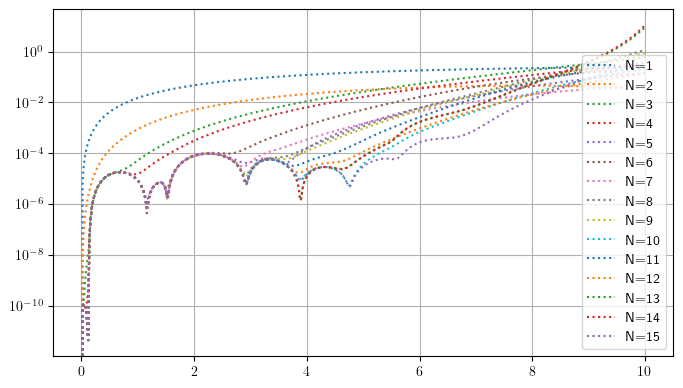

         t        n1            n2            n3            n4            n5  \
0     0.00  0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1     0.02  0.000008  9.850473e-09  4.955877e-11  5.143156e-11  5.300760e-11   
2     0.04  0.000030  7.801013e-08  1.338837e-10  1.111424e-10  1.139487e-10   
3     0.06  0.000067  2.613027e-07  6.568717e-10  1.136456e-10  1.177792e-10   
4     0.08  0.000119  6.150750e-07  2.160865e-09  8.191158e-11  7.420513e-11   
..     ...       ...           ...           ...           ...           ...   
496   9.92  0.246850  3.577270e-02  5.680841e-01  3.299487e-01  1.390791e-01   
497   9.94  0.247048  3.556138e-02  5.749332e-01  3.333594e-01  1.403301e-01   
498   9.96  0.247245  3.534742e-02  5.818709e-01  3.368046e-01  1.415831e-01   
499   9.98  0.247442  3.513082e-02  5.888985e-01  3.402846e-01  1.428381e-01   
500  10.00  0.247637  3.491156e-02  5.960171e-01  3.437998e-01  1.440949e-01   

               n6            n7        

In [ ]:
data = [ts]

plt.figure(figsize=(16/2,9/2))

for k, fun in enumerate(funs):
    xc_0 = R@x_0
    result = sp.integrate.solve_ivp(fun,[0,(Nt+1)*dt], xc_0, t_eval=ts)

    ys_c = []
    for j in range(result.y.shape[1]):
        ys_c.append(result.y[:,j].reshape([m,]))

    ys_c = np.array(ys_c)

    error = []
    for j in range(Nt+1):
        error.append(np.linalg.norm(ys[j,:]-ys_c[j,:]))
    error = np.array(error)

    data.append(error)
    
    plt.plot(ts,error, ':',label='N='+str(k+1))
plt.grid()
plt.yscale('log')
plt.legend()
plt.show()

header = ['t']+['n'+str(k) for k in range(1,len(funs)+1)]
df = pd.DataFrame(np.array(data).T, columns=header)
print(df)
np.savetxt('../data/errors.csv',data,)